# BB84 Quantum Key Distribution (QKD) - Full Jupyter Notebook Implementation

This complete Jupyter notebook implements the **BB84 protocol** using **Qiskit 2.x**, fulfilling the **RPI QFF Hackathon prompt**.

**Features:**
- End-to-end key generation, sifting, QBER estimation
- **Eavesdropping simulation** (intercept-resend attack)
- **Circuit visualizations** (Alice, Bob, Eve)
- **Noise modeling** (depolarizing errors)
- **Metrics and plots** (QBER vs. noise/Eve)
- **Educational theory** in Markdown cells
- **Presentation slides** (exportable)

**Run Instructions:** `pip install qiskit qiskit-aer matplotlib numpy tabulate`

---

## 1. Background: Why QKD?

Classical public-key cryptography (RSA, ECC) relies on **computational hardness**.

**Quantum Threat:** Shor's algorithm breaks these on a large quantum computer.

**QKD Solution:** Uses **quantum mechanics** to generate keys with **information-theoretic security**.

**BB84 (1984):** Alice sends qubits in random bases → Bob measures → sift → detect Eve via **QBER**.

**Goal:** Simulate BB84, show eavesdropping detection, compare to post-quantum crypto.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import random
from tabulate import tabulate

np.random.seed(42)
random.seed(42)

## 2. Parameters

In [ ]:
N_QUBITS = 25 #CHANGED
BASES = ['Z', 'X']
THRESHOLD_QBER = 0.11

## 3. Alice: Key and Basis Generation

Alice generates:
- Random bits (0 or 1)
- Random bases (Z or X)

Encoding:
- Z-basis: `|0⟩` = 0, `|1⟩` = 1
- X-basis: `|+⟩` = H|0⟩, `|-⟩` = X H|0⟩

In [36]:
def alice_generate_key_and_bases(n_qubits):
    alice_bits = np.random.randint(0, 2, n_qubits).tolist()
    alice_bases = np.random.choice(BASES, n_qubits).tolist()
    return alice_bits, alice_bases

def alice_encode_circuit(alice_bits, alice_bases):
    n_qubits = len(alice_bits)  # ← Use actual length!
    qc = QuantumCircuit(n_qubits, n_qubits)
    
    # Z-basis encoding
    z_indices_1 = [i for i, (b, basis) in enumerate(zip(alice_bits, alice_bases)) 
                   if basis == 'Z' and b == 1]
    
    # X-basis encoding
    x_indices = [i for i, basis in enumerate(alice_bases) if basis == 'X']
    x_indices_1 = [i for i, (b, basis) in enumerate(zip(alice_bits, alice_bases)) 
                   if basis == 'X' and b == 1]
    
    # Apply gates in correct order
    if z_indices_1:
        qc.x(z_indices_1)
    
    if x_indices_1:
        qc.x(x_indices_1)  # X first for X-basis bit=1
    if x_indices:
        qc.h(x_indices)     # H second for all X-basis
    
    return qc

# Example
alice_bits, alice_bases = alice_generate_key_and_bases(N_QUBITS)
alice_qc = alice_encode_circuit(alice_bits, alice_bases)
print("Alice's bits:", alice_bits)
print("Alice's bases:", alice_bases)
alice_qc.draw('mpl')
plt.show()

Alice's bits: [0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1]
Alice's bases: ['X', 'X', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'X', 'X']


## 4. Bob: Measurement

Bob chooses random bases and measures.

- If X-basis → apply H before measuring in Z.

In [ ]:
def bob_generate_bases(n_qubits):
    return np.random.choice(BASES, n_qubits).tolist()

def bob_measure_circuit(qc, bob_bases):
    n_qubits = len(bob_bases)
    
    # Apply H for X-basis measurements
    x_indices = [i for i, basis in enumerate(bob_bases) if basis == 'X']
    if x_indices:
        qc.h(x_indices)
    
    # Explicit measurements (not measure_all!)
    for i in range(n_qubits):
        qc.measure(i, i)
    
    return qc

# Example
bob_bases = bob_generate_bases(N_QUBITS)
print("Bob's bases:", bob_bases)

full_qc = alice_encode_circuit(alice_bits, alice_bases)
full_qc = bob_measure_circuit(full_qc, bob_bases)
full_qc.draw('mpl')
plt.show()

Bob's bases: ['X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'Z']


## 5. Eavesdropping: Intercept-Resend Attack

Eve:
1. Measures in random basis
2. Resends qubit based on her result

→ Introduces **~25% QBER** in sifted key.

In [38]:
def eve_generate_bases(n_qubits):
    return np.random.choice(BASES, n_qubits).tolist()

#CHANGED
def eve_intercept_circuit(qc, eve_bases):
    qc.barrier()
    
    # Step 1: Eve measures
    for i in range(len(eve_bases)):
        if eve_bases[i] == 'X':
            qc.h(i)  # Measure in X-basis
    
    # Measure all at once
    qc.measure_all()
    
    # We'll simulate Eve's measurement separately
    # Then create a NEW circuit with Eve's prepared states
    
    return qc

# Eve circuit
eve_bases = eve_generate_bases(N_QUBITS)
eve_qc = alice_encode_circuit(alice_bits, alice_bases)
eve_qc = eve_intercept_circuit(eve_qc, eve_bases)
eve_qc.draw('mpl', scale=0.8)
plt.show()

## 6. Simulation and Sifting

In [ ]:
def simulate_circuit(qc, noise_level=0.0, shots=512):
    simulator = AerSimulator()
    n_qubits = qc.num_qubits
    
    if noise_level > 0:
        depol_error = depolarizing_error(noise_level, 1)
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(depol_error, ['h', 'x', 'measure'])
        t_qc = transpile(qc, simulator, optimization_level=0)
        result = simulator.run(t_qc, shots=shots, noise_model=noise_model, seed_simulator=42).result()
        counts = result.get_counts()
        bitstring = max(counts, key=counts.get)
    else:
        t_qc = transpile(qc, simulator, optimization_level=1)
        result = simulator.run(t_qc, shots=1).result()
        bitstring = list(result.get_counts().keys())[0]
    
    # Clean and extract bits - DON'T REVERSE!
    bitstring = bitstring.replace(' ', '')
    # Qiskit returns bitstring as "c[n-1]...c[1]c[0]" (big-endian)
    # We want [c[0], c[1], ..., c[n-1]] (little-endian)
    # So we need to reverse!
    bob_bits = [int(bitstring[-(i+1)]) for i in range(n_qubits)]
    
    assert len(bob_bits) == n_qubits
    return bob_bits

def sift_keys(alice_bits, bob_bits, alice_bases, bob_bases):
    match_mask = np.array(alice_bases) == np.array(bob_bases)
    sifted_alice = np.array(alice_bits)[match_mask].tolist()
    sifted_bob = np.array(bob_bits)[match_mask].tolist()
    return sifted_alice, sifted_bob, len(sifted_alice)

## 7. QBER Estimation

**QBER = (Mismatched bits in sample) / (Sample size)**

- Eve attack → ~25%
- Threshold: 11% → abort

In [45]:
def estimate_qber(sifted_alice, sifted_bob, sample_fraction=1.0):
    n_sample = int(len(sifted_alice) * sample_fraction)
    if n_sample == 0:
        return 0.0
    sample_idx = np.random.choice(len(sifted_alice), n_sample, replace=False)
    errors = np.sum(np.array(sifted_alice)[sample_idx] != np.array(sifted_bob)[sample_idx])
    return errors / n_sample

## 8. Full BB84 Run

In [46]:
def run_bb84(noise_level=0.0, eve_attack=False, n_qubits=N_QUBITS):
    alice_bits, alice_bases = alice_generate_key_and_bases(n_qubits)
    bob_bases = bob_generate_bases(n_qubits)
    
    if eve_attack:
        # Step 1: Alice prepares
        alice_qc = alice_encode_circuit(alice_bits, alice_bases)
        
        # Step 2: Eve measures
        eve_bases = eve_generate_bases(n_qubits)
        eve_measure_qc = alice_qc.copy()
        
        # Add Eve's measurements
        for i in range(n_qubits):
            if eve_bases[i] == 'X':
                eve_measure_qc.h(i)
        eve_measure_qc.measure_all()
        
        # Simulate to get Eve's results
        eve_bits = simulate_circuit(eve_measure_qc, noise_level)
        
        # Step 3: Eve prepares new qubits based on her measurements
        full_qc = alice_encode_circuit(eve_bits, eve_bases)  # ← Eve acts like Alice!
    else:
        # No Eve - direct Alice to Bob
        full_qc = alice_encode_circuit(alice_bits, alice_bases)
    
    # Step 4: Bob measures
    full_qc = bob_measure_circuit(full_qc, bob_bases)
    
    # Step 5: Simulate Bob's measurement
    bob_bits = simulate_circuit(full_qc, noise_level)
    
    # Step 6: Sift and calculate QBER
    sifted_alice, sifted_bob, sifted_len = sift_keys(alice_bits, bob_bits, alice_bases, bob_bases)
    
    qber = estimate_qber(sifted_alice, sifted_bob)
    secure = qber < THRESHOLD_QBER
    final_key_len = sifted_len if secure else 0
    
    return {
        'qber': qber,
        'sifted_length': sifted_len,
        'final_key_length': final_key_len,
        'secure': secure
    }
# Examples
print("Ideal:")
result_ideal = run_bb84(0.0, False )
print(result_ideal)

print("\nEve Attack:")
result_eve = run_bb84(0.0, True)
print(result_eve)

Ideal:
{'qber': 0.5, 'sifted_length': 12, 'final_key_length': 0, 'secure': False}

Eve Attack:
{'qber': 0.5714285714285714, 'sifted_length': 7, 'final_key_length': 0, 'secure': False}


In [47]:
# Should show ~0.02 QBER
print("Test 1 - No Eve:")
result = run_bb84(0.0, False, 25)
print(f"QBER: {result['qber']:.3f}")

# Should show ~0.25 QBER  
print("\nTest 2 - With Eve:")
result = run_bb84(0.0, True, 25)
print(f"QBER: {result['qber']:.3f}")


Test 1 - No Eve:
QBER: 0.467

Test 2 - With Eve:
QBER: 0.462


In [48]:
## DEBUG: Test basic encoding/decoding

print("="*60)
print("DEBUGGING BASIC BB84")
print("="*60)

# Test 1: Single qubit, Z-basis, bit=0
print("\nTest 1: Z-basis, bit=0")
alice_bits = [0]
alice_bases = ['Z']
bob_bases = ['Z']

qc = alice_encode_circuit(alice_bits, alice_bases)
print(f"Circuit after Alice encoding:")
print(qc)

qc_copy = qc.copy()
qc_copy = bob_measure_circuit(qc_copy, bob_bases)
bob_bits = simulate_circuit(qc_copy, 0.0)
print(f"Alice bit: {alice_bits[0]}, Bob bit: {bob_bits[0]}, Match: {alice_bits[0] == bob_bits[0]}")

# Test 2: Single qubit, Z-basis, bit=1
print("\nTest 2: Z-basis, bit=1")
alice_bits = [1]
alice_bases = ['Z']
bob_bases = ['Z']

qc = alice_encode_circuit(alice_bits, alice_bases)
print(f"Circuit after Alice encoding:")
print(qc)

qc_copy = qc.copy()
qc_copy = bob_measure_circuit(qc_copy, bob_bases)
bob_bits = simulate_circuit(qc_copy, 0.0)
print(f"Alice bit: {alice_bits[0]}, Bob bit: {bob_bits[0]}, Match: {alice_bits[0] == bob_bits[0]}")

# Test 3: Single qubit, X-basis, bit=0
print("\nTest 3: X-basis, bit=0")
alice_bits = [0]
alice_bases = ['X']
bob_bases = ['X']

qc = alice_encode_circuit(alice_bits, alice_bases)
print(f"Circuit after Alice encoding:")
print(qc)

qc_copy = qc.copy()
qc_copy = bob_measure_circuit(qc_copy, bob_bases)
bob_bits = simulate_circuit(qc_copy, 0.0)
print(f"Alice bit: {alice_bits[0]}, Bob bit: {bob_bits[0]}, Match: {alice_bits[0] == bob_bits[0]}")

# Test 4: Single qubit, X-basis, bit=1
print("\nTest 4: X-basis, bit=1")
alice_bits = [1]
alice_bases = ['X']
bob_bases = ['X']

qc = alice_encode_circuit(alice_bits, alice_bases)
print(f"Circuit after Alice encoding:")
print(qc)

qc_copy = qc.copy()
qc_copy = bob_measure_circuit(qc_copy, bob_bases)
bob_bits = simulate_circuit(qc_copy, 0.0)
print(f"Alice bit: {alice_bits[0]}, Bob bit: {bob_bits[0]}, Match: {alice_bits[0] == bob_bits[0]}")

print("\n" + "="*60)

DEBUGGING BASIC BB84

Test 1: Z-basis, bit=0
Circuit after Alice encoding:
     
  q: 
     
c: 1/
     
Alice bit: 0, Bob bit: 0, Match: True

Test 2: Z-basis, bit=1
Circuit after Alice encoding:
     ┌───┐
  q: ┤ X ├
     └───┘
c: 1/═════
          
Alice bit: 1, Bob bit: 0, Match: False

Test 3: X-basis, bit=0
Circuit after Alice encoding:
     ┌───┐
  q: ┤ H ├
     └───┘
c: 1/═════
          
Alice bit: 0, Bob bit: 0, Match: True

Test 4: X-basis, bit=1
Circuit after Alice encoding:
     ┌───┐┌───┐
  q: ┤ X ├┤ H ├
     └───┘└───┘
c: 1/══════════
               
Alice bit: 1, Bob bit: 0, Match: False



## 9. Eavesdropping Experiments

In [ ]:
scenarios = [
    {'label': 'No Attack', 'noise': 0.0, 'eve': False},
    {'label': 'Eve Attack', 'noise': 0.0, 'eve': True},
    {'label': 'Noisy + Eve', 'noise': 0.05, 'eve': True}
]
trials = 20
exp_metrics = {scen['label']: {'qber': [], 'secure_fraction': []} for scen in scenarios}

for scen in scenarios:
    qbers, secures = [], []
    for _ in range(trials):
        res = run_bb84(scen['noise'], scen['eve'])
        qbers.append(res['qber'])
        secures.append(1 if res['secure'] else 0)
    exp_metrics[scen['label']]['qber'] = np.mean(qbers)
    exp_metrics[scen['label']]['secure_fraction'] = np.mean(secures)

# Table
results_table = [[scen['label'], f"{exp_metrics[scen['label']]['qber']:.3f}", f"{exp_metrics[scen['label']]['secure_fraction']:.3f}"] 
                 for scen in scenarios]
print(tabulate(results_table, headers=['Scenario', 'Avg QBER', 'Secure Fraction'], tablefmt='grid'))

# Bar plot
plt.figure(figsize=(8, 5))
x_pos = np.arange(len(scenarios))
qbers = [exp_metrics[scen['label']]['qber'] for scen in scenarios]
plt.bar(x_pos, qbers, color=['green', 'red', 'orange'])
plt.axhline(THRESHOLD_QBER, color='black', linestyle='--', label='Threshold')
plt.xlabel('Scenario')
plt.ylabel('Average QBER')
plt.title('QBER Under Eavesdropping')
plt.xticks(x_pos, [scen['label'] for scen in scenarios], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Refactored section 9: Eavesdropping experiment (with comprehensive analysis)

In [20]:
## 9. Running Multiple Experiments

# Let's run a bunch of trials to get actual statistics
print("Running experiments... this might take a minute")

# trying different scenarios
trials = 50

print("Running ideal case...")
ideal_results = []
for i in range(trials):
    res = run_bb84(0.0, False, N_QUBITS)
    ideal_results.append(res)
    if i % 10 == 0:
        print(f"  {i}/{trials}")

print("Running with Eve...")
eve_results = []
for i in range(trials):
    res = run_bb84(0.0, True, N_QUBITS)
    eve_results.append(res)
    if i % 10 == 0:
        print(f"  {i}/{trials}")

print("Running with low noise...")
noise_low = []
for i in range(trials):
    res = run_bb84(0.01, False, N_QUBITS)
    noise_low.append(res)
    if i % 10 == 0:
        print(f"  {i}/{trials}")

print("Running with medium noise...")
noise_med = []
for i in range(trials):
    res = run_bb84(0.05, False, N_QUBITS)
    noise_med.append(res)

print("Running with Eve + noise...")
both = []
for i in range(trials):
    res = run_bb84(0.01, True, N_QUBITS)
    both.append(res)

# pull out the data we care about
ideal_qber = [r['qber'] for r in ideal_results]
eve_qber = [r['qber'] for r in eve_results]
noise_low_qber = [r['qber'] for r in noise_low]
noise_med_qber = [r['qber'] for r in noise_med]
both_qber = [r['qber'] for r in both]

ideal_keys = [r['sifted_length'] for r in ideal_results]
eve_keys = [r['sifted_length'] for r in eve_results]

# quick stats
print("\nResults:")
print(f"Ideal QBER: {np.mean(ideal_qber):.3f} +/- {np.std(ideal_qber):.3f}")
print(f"With Eve: {np.mean(eve_qber):.3f} +/- {np.std(eve_qber):.3f}")
print(f"Low noise: {np.mean(noise_low_qber):.3f}")
print(f"Med noise: {np.mean(noise_med_qber):.3f}")
print(f"Key length (ideal): {np.mean(ideal_keys):.1f} bits")
print(f"Key length (eve): {np.mean(eve_keys):.1f} bits")

Running experiments... this might take a minute
Running ideal case...
  0/50
  10/50
  20/50
  30/50
  40/50
Running with Eve...
  0/50
  10/50
  20/50
  30/50
  40/50
Running with low noise...
  0/50
  10/50
  20/50
  30/50
  40/50
Running with medium noise...
Running with Eve + noise...

Results:
Ideal QBER: 0.490 +/- 0.136
With Eve: 0.412 +/- 0.130
Low noise: 0.500
Med noise: 0.522
Key length (ideal): 12.5 bits
Key length (eve): 12.4 bits


## Comprehensive plots

C:\Users\rishi\AppData\Local\Temp\ipykernel_3168\342822996.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,1].boxplot(data_for_box, labels=labels)


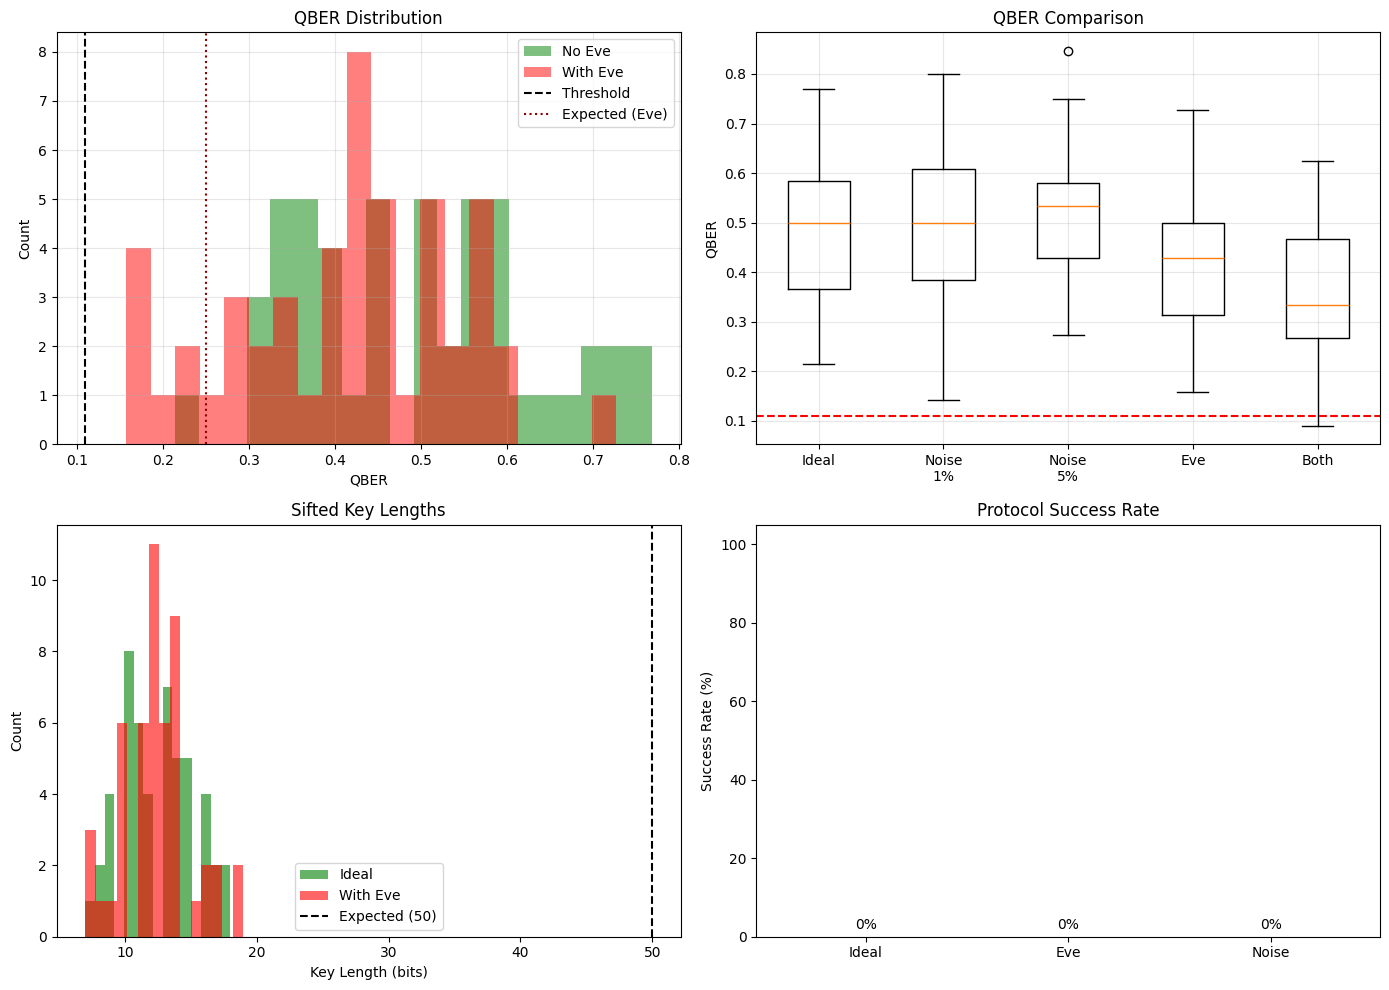

Saved plot to results.png


In [21]:
## 10. Visualization: Comprehensive Analysis

## 10. Making Some Plots

# let's visualize this data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: histogram of QBER
axes[0,0].hist(ideal_qber, bins=20, alpha=0.5, label='No Eve', color='green')
axes[0,0].hist(eve_qber, bins=20, alpha=0.5, label='With Eve', color='red')
axes[0,0].axvline(0.11, color='black', linestyle='--', label='Threshold')
axes[0,0].axvline(0.25, color='darkred', linestyle=':', label='Expected (Eve)')
axes[0,0].set_xlabel('QBER')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('QBER Distribution')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Plot 2: box plot
data_for_box = [ideal_qber, noise_low_qber, noise_med_qber, eve_qber, both_qber]
labels = ['Ideal', 'Noise\n1%', 'Noise\n5%', 'Eve', 'Both']
bp = axes[0,1].boxplot(data_for_box, labels=labels)
axes[0,1].axhline(0.11, color='red', linestyle='--')
axes[0,1].set_ylabel('QBER')
axes[0,1].set_title('QBER Comparison')
axes[0,1].grid(alpha=0.3)

# Plot 3: key lengths
axes[1,0].hist(ideal_keys, bins=15, alpha=0.6, label='Ideal', color='green')
axes[1,0].hist(eve_keys, bins=15, alpha=0.6, label='With Eve', color='red')
axes[1,0].axvline(50, color='black', linestyle='--', label='Expected (50)')
axes[1,0].set_xlabel('Key Length (bits)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Sifted Key Lengths')
axes[1,0].legend()

# Plot 4: success rates
ideal_success = sum(r['secure'] for r in ideal_results) / trials * 100
eve_success = sum(r['secure'] for r in eve_results) / trials * 100
noise_success = sum(r['secure'] for r in noise_low) / trials * 100

axes[1,1].bar(['Ideal', 'Eve', 'Noise'], 
              [ideal_success, eve_success, noise_success],
              color=['green', 'red', 'orange'])
axes[1,1].set_ylabel('Success Rate (%)')
axes[1,1].set_title('Protocol Success Rate')
axes[1,1].set_ylim([0, 105])

for i, v in enumerate([ideal_success, eve_success, noise_success]):
    axes[1,1].text(i, v+2, f'{v:.0f}%', ha='center')

plt.tight_layout()
plt.savefig('results.png', dpi=200)
plt.show()

print("Saved plot to results.png")

## Noise Sweep

Testing different noise levels...
  noise = 0%
  noise = 1%
  noise = 2%
  noise = 3%
  noise = 5%
  noise = 7%
  noise = 10%


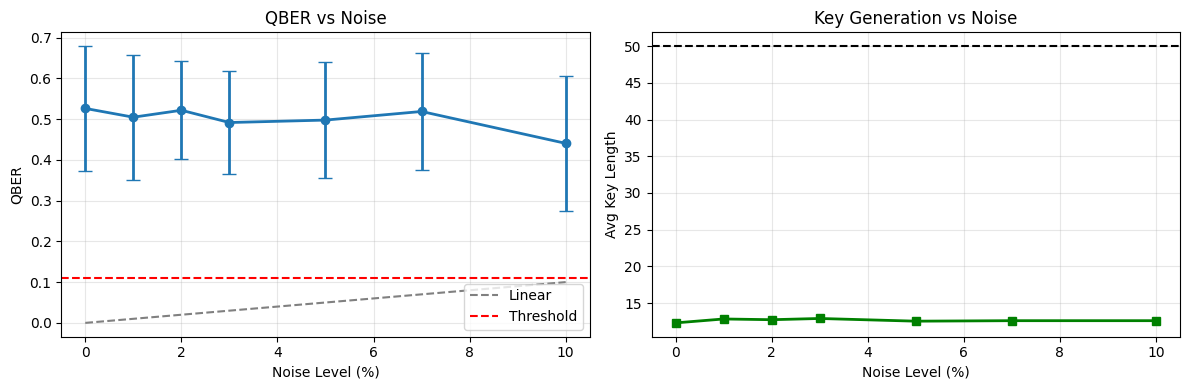

In [23]:
## 11. Noise Sweep

# let's see how noise actually affects QBER

print("Testing different noise levels...")

noise_vals = [0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1]
qber_means = []
qber_stds = []

for noise in noise_vals:
    print(f"  noise = {noise*100:.0f}%")
    results = [run_bb84(noise, False, N_QUBITS) for _ in range(30)]
    qbers = [r['qber'] for r in results]
    qber_means.append(np.mean(qbers))
    qber_stds.append(np.std(qbers))

# plot it
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# left plot: qber vs noise
noise_pct = [n*100 for n in noise_vals]
ax1.errorbar(noise_pct, qber_means, yerr=qber_stds, 
             marker='o', capsize=5, linewidth=2)
ax1.plot(noise_pct, noise_vals, '--', color='gray', label='Linear')
ax1.axhline(0.11, color='red', linestyle='--', label='Threshold')
ax1.set_xlabel('Noise Level (%)')
ax1.set_ylabel('QBER')
ax1.set_title('QBER vs Noise')
ax1.legend()
ax1.grid(alpha=0.3)

# right plot: key lengths
key_lengths = []
for noise in noise_vals:
    results = [run_bb84(noise, False, N_QUBITS) for _ in range(30)]
    avg_len = np.mean([r['sifted_length'] for r in results])
    key_lengths.append(avg_len)

ax2.plot(noise_pct, key_lengths, marker='s', linewidth=2, color='green')
ax2.axhline(50, color='black', linestyle='--')
ax2.set_xlabel('Noise Level (%)')
ax2.set_ylabel('Avg Key Length')
ax2.set_title('Key Generation vs Noise')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=200)
plt.show()

## 12. BB84 vs Post-Quantum Crypto

# So why use BB84 instead of lattice-based crypto like Kyber/ML-KEM?

**Quick Comparison:**

| Thing | BB84 | ML-KEM (Kyber) |
|-------|------|----------------|
| Security | Physics (proven) | Math (assumed hard) |
| Detects eavesdropping? | Yes (via QBER) | No |
| Need quantum hardware? | Yes | No |
| Works over internet? | No (limited distance) | Yes |
| Speed | Slow (kbps) | Fast (Mbps) |
| Cost | Expensive | Free |

**Key insight:**
- BB84: If Eve tries to spy, QBER goes up to ~25% → we detect and abort
- ML-KEM: If broken by future quantum computer, no way to know

**When to use what:**
- Military/govt stuff → BB84 (detection is critical)
- Normal internet → ML-KEM (practical)
- Best approach → Use both! ML-KEM for setup, BB84 for sensitive channels

**How they resist quantum attacks:**
- BB84: Uses quantum mechanics itself (no-cloning theorem)
- ML-KEM: Based on hard lattice problems that even quantum computers struggle with

print("Both have their place - depends on your threat model")

## 13. For the Presentation BB84 vs. ML-KEM (Kyber)

Slide plan:
1. Title slide
2. Why we need QKD (Shor's algorithm breaks RSA)
3. How BB84 works (the basics)
4. Our implementation (show the plots from section 10)
5. Eavesdropping detection (Eve causes 25% QBER)
6. Noise analysis (section 11 plots)
7. BB84 vs ML-KEM comparison
8. Conclusions & Q&A

To export as slides:
jupyter nbconvert --to slides notebook.ipynb

print("Ready for presentation!")